In [1]:
import torch
import pandas as pd

df = pd.read_csv("F:\PythonCode\data\\bank-additional-train.csv")

In [4]:
df = df.drop(columns=['user_id'])

In [9]:
df['default'].head(20)

0      no
1     NaN
2      no
3      no
4      no
5      no
6      no
7     NaN
8      no
9      no
10     no
11     no
12     no
13     no
14     no
15     no
16     no
17     no
18     no
19     no
Name: default, dtype: object

In [10]:
# 1. 加载数据
train_df = pd.read_csv("F:\PythonCode\data\\bank-additional-train.csv")
test_df = pd.read_csv("F:\PythonCode\data\\bank-additional-test.csv")

# 2. 查看基本信息
print("--- 训练集基本信息 ---")
print(train_df.info())
print("\n--- 缺失值统计 ---")
print(train_df.isnull().sum())

# 3. 查看目标变量 y 的分布 (判定是否存在类别不平衡)
print("\n--- 目标变量分布 ---")
print(train_df['y'].value_counts(normalize=True))

# 4. 查看数值型特征的描述统计
print("\n--- 数值特征描述 ---")
print(train_df.describe())

# 5. 查看前几行数据
print(train_df.head())

--- 训练集基本信息 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         32950 non-null  object 
 1   age             32950 non-null  int64  
 2   job             32686 non-null  object 
 3   marital         32885 non-null  object 
 4   education       31564 non-null  object 
 5   default         26084 non-null  object 
 6   housing         32168 non-null  object 
 7   loan            32168 non-null  object 
 8   contact         32950 non-null  object 
 9   month           32950 non-null  object 
 10  day_of_week     32950 non-null  object 
 11  duration        32950 non-null  int64  
 12  campaign        32950 non-null  int64  
 13  pdays           32950 non-null  int64  
 14  previous        32950 non-null  int64  
 15  poutcome        32950 non-null  object 
 16  emp.var.rate    32950 non-null  float64
 17  cons.price.idx 

In [12]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [13]:
def preprocess_data(df):
    # 拷贝数据避免警告
    data = df.copy()
    
    # 1. 处理缺失值：将 Object 类型的缺失值填补为 'unknown'
    cat_cols = data.select_dtypes(include=['object']).columns
    for col in cat_cols:
        data[col] = data[col].fillna('unknown')
    
    # 2. 特征工程：pdays
    # 999表示从未联系，我们增加一个特征表示是否被联系过
    data['pcontacted'] = (data['pdays'] != 999).astype(int)
    
    # 3. 删除对预测无直接意义的 ID
    if 'user_id' in data.columns:
        data.drop('user_id', axis=1, inplace=True)
    
    # 4. 目标变量转换 (yes -> 1, no -> 0)
    if 'y' in data.columns:
        data['y'] = data['y'].map({'yes': 1, 'no': 0})
    
    # 5. 类别变量编码 (Label Encoding 适合树模型)
    le = LabelEncoder()
    object_cols = data.select_dtypes(include=['object']).columns
    for col in object_cols:
        data[col] = le.fit_transform(data[col])
        
    return data

# 应用预处理
train_processed = preprocess_data(train_df)
test_processed = preprocess_data(test_df)

# 查看处理后的相关性
print("--- 目标变量相关性排序 ---")
print(train_processed.corr()['y'].sort_values(ascending=False))

--- 目标变量相关性排序 ---
y                 1.000000
duration          0.403035
pcontacted        0.327298
previous          0.237298
poutcome          0.128243
education         0.059185
cons.conf.idx     0.054224
marital           0.046976
age               0.028995
job               0.024306
housing           0.014020
day_of_week       0.010838
month            -0.004765
loan             -0.008572
campaign         -0.068686
default          -0.097696
cons.price.idx   -0.134376
contact          -0.144008
emp.var.rate     -0.297814
euribor3m        -0.308316
pdays            -0.327284
nr.employed      -0.356101
Name: y, dtype: float64


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 准备训练数据
X = train_processed.drop('y', axis=1)
y = train_processed['y']

# 划分验证集 (为了查看模型效果)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 初始化模型 (平衡类别权重)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 预测结果
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# 输出评估指标
print("\n--- 模型评估报告 ---")
print(classification_report(y_val, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob):.4f}")


--- 模型评估报告 ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      5849
           1       0.71      0.45      0.55       741

    accuracy                           0.92      6590
   macro avg       0.82      0.71      0.75      6590
weighted avg       0.91      0.92      0.91      6590

ROC-AUC Score: 0.9458


In [19]:
train_processed.head(), test_processed.head()

(   age  job  marital  education  default  housing  loan  contact  month  \
 0   34    1        1          2        0        2     2        1      6   
 1   36    0        1          6        1        2     0        1      6   
 2   35    6        2          6        0        2     0        0      3   
 3   29    1        1          3        0        2     0        1      7   
 4   53    6        1          0        0        0     0        1      6   
 
    day_of_week  ...  pdays  previous  poutcome  emp.var.rate  cons.price.idx  \
 0            4  ...    999         0         1           1.1          93.994   
 1            3  ...    999         0         1           1.1          93.994   
 2            2  ...    999         0         1           1.4          93.918   
 3            2  ...    999         0         1          -0.1          93.200   
 4            3  ...    999         0         1           1.1          93.994   
 
    cons.conf.idx  euribor3m  nr.employed  y  pcontact

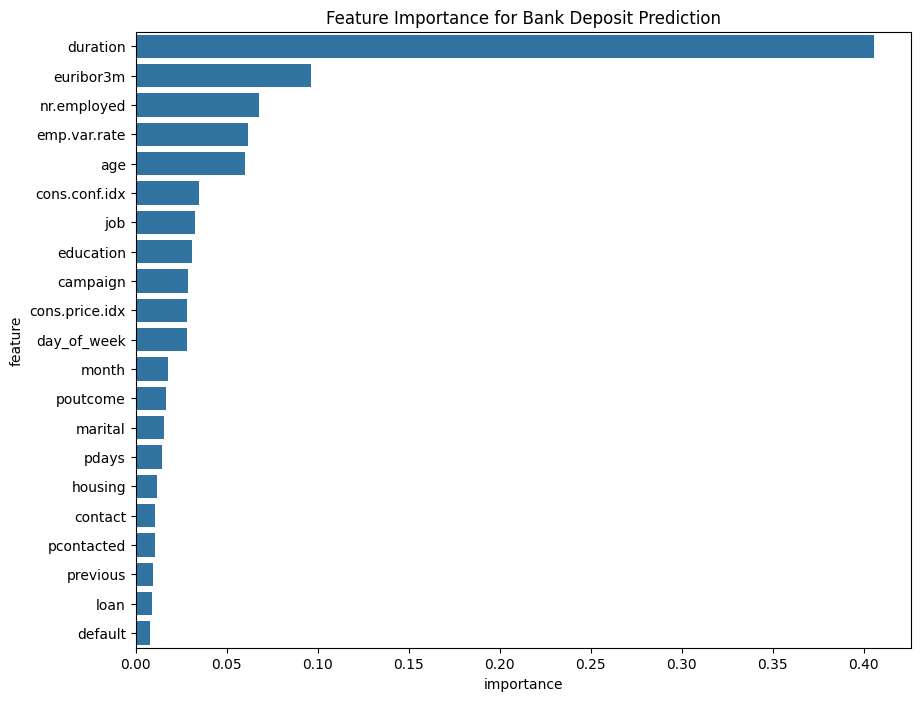

--- 前 10 个关键影响因素 ---
           feature  importance
10        duration    0.405610
18       euribor3m    0.096607
19     nr.employed    0.068025
15    emp.var.rate    0.061517
0              age    0.060292
17   cons.conf.idx    0.034595
1              job    0.032613
3        education    0.031061
11        campaign    0.028803
16  cons.price.idx    0.028438


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 获取特征重要性
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# 可视化
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance for Bank Deposit Prediction')
plt.show()

# 打印前 10 个最重要的特征
print("--- 前 10 个关键影响因素 ---")
print(feature_importance_df.head(10))

In [20]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:

# 1. 区分特征类型
numeric_features = ['age', 'duration', 'campaign', 'pdays', 'previous', 
                    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 
                        'loan', 'contact', 'month', 'day_of_week', 'poutcome']

# 2. 构造预处理管道 (标准化数值 + One-Hot 编码类别)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. 转换数据
X = train_df.drop(['user_id', 'y'], axis=1)
y = train_df['y'].map({'yes': 1, 'no': 0}).values

X_processed = preprocessor.fit_transform(X)
if hasattr(X_processed, 'toarray'): # 处理稀疏矩阵
    X_processed = X_processed.toarray()

# 4. 转换为 PyTorch 张量并移动到 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用设备: {device}")

X_tensor = torch.FloatTensor(X_processed).to(device)
y_tensor = torch.FloatTensor(y).view(-1, 1).to(device)

# 划分训练集和验证集
train_size = int(0.8 * len(X_tensor))
X_train, X_val = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_val = y_tensor[:train_size], y_tensor[train_size:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)

当前使用设备: cuda


In [26]:
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, dim, dropout_rate):
        super(ResBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        # 残差连接：输入 + 变换后的结果
        return self.relu(x + self.block(x))

class BankPredictorResNet(nn.Module):
    def __init__(self, input_dim):
        super(BankPredictorResNet, self).__init__()
        
        # 第一层：将输入映射到更高维空间
        self.first_layer = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )
        
        # 核心：两个残差块
        self.res_block1 = ResBlock(256, 0.3)
        self.res_block2 = ResBlock(256, 0.3)
        
        # 输出层：逐步降维
        self.output_layer = nn.Sequential(
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.first_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        return self.output_layer(x)

# 实例化


input_dim = X_processed.shape[1]
model = BankPredictorResNet(input_dim).to(device)

# 处理类别不平衡：计算 pos_weight
pos_weight = torch.tensor([(len(y) - sum(y)) / sum(y)]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # 使用带权重的损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [27]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report

# 建议：为了数值稳定性，如果模型最后有 Sigmoid，使用 BCELoss
# 针对 11% 的类别不平衡，我们可以手动给正样本（y=1）增加权重
# 这里我们假设正样本权重为 8（因为 88%/11% 约等于 8）
weight = torch.tensor([8.0]).to(device)

def get_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

epochs = 50
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        
        # 使用带权重的损失函数处理不平衡 [cite: 3, 15]
        # 注意：这里我们简单使用 BCELoss，如果需要更精确的控制，可以换成 BCEWithLogitsLoss
        loss = nn.BCELoss()(outputs, batch_y) 
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # 每 10 轮输出详细指标
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_probs = model(X_val).cpu().numpy()
            y_true = y_val.cpu().numpy()
            
            # 计算各项指标 (阈值设为 0.5)
            auc = roc_auc_score(y_true, val_probs)
            acc, prec, rec, f1 = get_metrics(y_true, val_probs, threshold=0.5)
            
            print(f"\n--- Epoch [{epoch+1}/{epochs}] ---")
            print(f"Loss: {train_loss/len(train_loader):.4f}")
            print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
            
            # 如果是最后一轮，打印详细报告
            if (epoch + 1) == epochs:
                print("\n最终分类报告 (Final Classification Report):")
                y_pred = (val_probs >= 0.5).astype(int)
                print(classification_report(y_true, y_pred, target_names=['No (0)', 'Yes (1)']))


--- Epoch [10/50] ---
Loss: 0.1635
Accuracy: 0.9162 | Precision: 0.6385 | Recall: 0.5597 | F1: 0.5965 | AUC: 0.9425

--- Epoch [20/50] ---
Loss: 0.1378
Accuracy: 0.9132 | Precision: 0.6129 | Recall: 0.5844 | F1: 0.5983 | AUC: 0.9339

--- Epoch [30/50] ---
Loss: 0.1083
Accuracy: 0.9058 | Precision: 0.5687 | Recall: 0.6132 | F1: 0.5901 | AUC: 0.9304

--- Epoch [40/50] ---
Loss: 0.0852
Accuracy: 0.9017 | Precision: 0.5636 | Recall: 0.4925 | F1: 0.5256 | AUC: 0.9204

--- Epoch [50/50] ---
Loss: 0.0705
Accuracy: 0.8961 | Precision: 0.5300 | Recall: 0.5336 | F1: 0.5318 | AUC: 0.9203

最终分类报告 (Final Classification Report):
              precision    recall  f1-score   support

      No (0)       0.94      0.94      0.94      5861
     Yes (1)       0.53      0.53      0.53       729

    accuracy                           0.90      6590
   macro avg       0.74      0.74      0.74      6590
weighted avg       0.90      0.90      0.90      6590

